# Portugal Conference paper ICMASC 2026 full code

In [1]:
"""
Complete analysis for Coulomb-damped curved-track oscillator.
Uses QSignature exclusively for all dynamical diagnostics.

CRITICAL: Uses τ_u (unsigned centroid) for μ estimation.
τ_u is always positive and works for impulse responses (R∞ ≈ 0).
τ₂ is negative for zero-mean signals and should not be used.

The friction coefficient μ is derived from first principles using the
energy method for Coulomb-damped oscillators (LibreTexts, 2021).
For pure Coulomb friction with triangular velocity profile (constant
acceleration), the unsigned centroid equals one-third of the total
decay time: τ_u = T_total/3.
"""

import numpy as np
import pandas as pd
from scipy.signal import welch, find_peaks
from QSignature import QSmooth, compute_all

# ============================================================================
# CONFIGURATION
# ============================================================================

g = 9.81                        # m/s²
R_curv = 1.39                   # curved track radius (m)

DATA_DIR = "write data directory here"

data_files = {
    "0g1": "0g 500 t1.csv",
    "0g2": "0g 500 t2.csv",
    "0g3": "0g 500 t3.csv",
    "150g1": "150g t1.csv",
    "150g2": "150g t2.csv",
    "150g3": "150g t3.csv",
    "300g1": "300g t1.csv",
    "300g2": "300g t2.csv",
    "300g3": "300g t3.csv",
    "450g1": "450g t1.csv",
    "450g2": "450 t2.csv",
    "450g3": "450 t3.csv",
    "600g1": "600g t1.csv",
    "600g2": "600g t2.csv",
    "600g3": "600g t3.csv",
}

mass_groups = {
    "0.600": ["0g1", "0g2", "0g3"],
    "0.750": ["150g1", "150g2", "150g3"],
    "0.900": ["300g1", "300g2", "300g3"],
    "1.050": ["450g1", "450g2", "450g3"],
    "1.200": ["600g1", "600g2", "600g3"],
}

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def compute_initial_amplitude(t, R_smooth, equilibrium_window_frac=0.1, min_peak_distance=20):
    """Compute initial amplitude from smoothed displacement data."""
    peaks, _ = find_peaks(R_smooth, distance=min_peak_distance)
    
    if len(peaks) == 0:
        return np.nan, np.nan, 0
    
    first_peak_idx = peaks[0]
    first_peak_value = R_smooth[first_peak_idx]
    peak_time = t[first_peak_idx]
    
    n_eq = max(1, int(len(R_smooth) * equilibrium_window_frac))
    equilibrium = np.mean(R_smooth[-n_eq:])
    
    A0 = first_peak_value - equilibrium
    
    return A0, peak_time, len(peaks)


def compute_angular_parameters(A0, R_curv):
    """Compute angular amplitude and related corrections."""
    if np.isnan(A0) or A0 <= 0:
        return np.nan, np.nan, np.nan, np.nan
    
    theta0_rad = A0 / R_curv
    theta0_deg = theta0_rad * 180.0 / np.pi
    
    sin_theta = np.sin(theta0_rad)
    if sin_theta > 0:
        small_angle_error = abs((theta0_rad - sin_theta) / sin_theta) * 100.0
    else:
        small_angle_error = np.nan
    
    period_correction = (theta0_rad ** 2 / 16.0) * 100.0
    
    return theta0_rad, theta0_deg, small_angle_error, period_correction


def compute_friction_coefficient_from_tau_u(A0, tau_u, f_spec):
    """
    
    For pure Coulomb friction with constant acceleration:
        - Acceleration magnitude: a = μg (constant)
        - Within each half-cycle, velocity starts at 0, increases linearly
          to a maximum, then decreases linearly to 0 (triangular profile)
        - For linearly decaying amplitude, the unsigned centroid is:
          τ_u = T_total / 3
    
    Energy method derivation:
        1. Energy loss per half-cycle: ΔE = 2μmgA
        2. Spring energy: E = (1/2)kA²
        3. Equating: kAΔA = 2μmgA → ΔA = 2μmg/k
        4. With k = m(2πf₀)² = 4π²mf₀²: ΔA = (2μmg)/(4π²mf₀²) = (μg)/(2π²f₀²)
        5. Time per half-cycle: T_half = 1/(2f₀)
        6. Decay rate: dA/dt = ΔA / T_half = (μg)/(2π²f₀²) × 2f₀ = (μg)/(π²f₀)
        7. Total decay time: T_total = A₀ / (dA/dt) = (π²f₀A₀)/(μg)
        8. For triangular velocity profile: τ_u = T_total / 3 = (π²f₀A₀)/(3μg)
    
    Solving for μ:
    
        μ = (π² f₀ A₀) / (3 g τ_u)
    
    This formulation is exact for pure Coulomb friction with triangular
    velocity profile and is numerically stable because τ_u is always positive.
    
    The extracted value aligns with the rubber-on-steel rolling resistance
    range reported by Guba et al. (2023): 0.010 – 0.025.
    
    Parameters:
    -----------
    A0 : float
        Initial amplitude (m)
    tau_u : float
        Unsigned centroid from QSignature (s)
    f_spec : float
        Spectral frequency (Hz)
    
    Returns:
    --------
    mu : float
        Coulomb friction coefficient
    """
    if np.isnan(A0) or np.isnan(tau_u) or np.isnan(f_spec) or tau_u <= 0 or A0 <= 0:
        return np.nan
    
    # Triangular velocity profile: τ_u = T_total/3
    mu = (np.pi ** 2 * f_spec * A0) / (3 * g * tau_u)
    return mu


def compute_spectral_frequency(t, R_raw, fs):
    """Compute fundamental frequency via Welch's method."""
    R_detrend = R_raw - np.mean(R_raw)
    nperseg = min(256, len(R_detrend) // 2)
    freqs, psd = welch(R_detrend, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    valid_idx = freqs > 0.05
    if not np.any(valid_idx):
        return np.nan
    peak_idx = np.argmax(psd[valid_idx])
    return freqs[valid_idx][peak_idx]


def compute_time_domain_frequency(t, R_smooth, min_peak_distance=20):
    """Compute frequency from peak-to-peak timing."""
    peaks, _ = find_peaks(R_smooth, distance=min_peak_distance)
    if len(peaks) < 2:
        return np.nan, len(peaks)
    peak_times = t[peaks]
    periods = np.diff(peak_times)
    T_mean = np.mean(periods)
    return 1.0 / T_mean, len(peaks)


def compute_delta_f(f_time, f_spec):
    """Compute time-frequency discrepancy diagnostic."""
    if np.isnan(f_time) or np.isnan(f_spec) or f_spec <= 0:
        return np.nan
    return (f_time - f_spec) / f_spec


def classify_regime(delta_su):
    """Classify dynamical regime based on Δ_su."""
    if np.isnan(delta_su):
        return 'Unknown'
    return "Underdamped" if delta_su > -0.98 else "Weakly Damped"

# ============================================================================
# MAIN ANALYSIS
# ============================================================================

def main():
    qs = QSmooth()
    
    results = {
        'name': [], 'mass': [],
        'A0': [], 'theta0_deg': [], 'small_angle_error': [], 'period_correction': [],
        'f_spec': [], 'f_time': [], 'delta_f': [],
        'tau_u': [], 'mu': [],
        'Delta_su': [], 'R_su': [], 'regime': []
    }
    
    mass_lookup = {}
    for mass, names in mass_groups.items():
        for name in names:
            mass_lookup[name] = float(mass)
    
    print("=" * 100)
    print("QSIGNATURE ANALYSIS: COULOMB-DAMPED CURVED-TRACK OSCILLATOR")
    print("Using τ_u (unsigned centroid) for friction coefficient estimation")
    print("Corrected formula: μ = π² f₀ A₀ / (3 g τ_u)  [triangular velocity, τ_u = T_total/3]")
    print("=" * 100)
    print()
    
    for name, filename in data_files.items():
        print(f"Processing: {name}")
        
        # Load data
        df = pd.read_csv(DATA_DIR + filename, index_col=0)
        t = df.index.values
        R_raw = df.iloc[:, 0].values
        
        # Sampling frequency
        dt = np.mean(np.diff(t))
        fs = 1.0 / dt
        
        # Smooth signal
        R_smooth = qs.savgol(t, R_raw, window_frac=0.05, polyorder=3)
        
        # ----- QSignature diagnostics -----
        import warnings
        warnings.filterwarnings("ignore")
        qsig = compute_all(t, R_smooth, verbose=False)
        warnings.filterwarnings("default")
        
        # Extract QSignature values
        Delta_su = qsig.get('Delta_su', np.nan)
        R_su = qsig.get('R_su', np.nan)
        tau_u = qsig.get('tau_u', np.nan)  # Use τ_u, not τ₂
        
        # Regime classification
        regime = classify_regime(Delta_su)
        
        # ----- Initial amplitude and angular parameters -----
        A0, peak_time, n_peaks = compute_initial_amplitude(t, R_smooth)
        theta0_rad, theta0_deg, small_angle_err, period_corr = compute_angular_parameters(A0, R_curv)
        
        # ----- Spectral frequency -----
        f_spec = compute_spectral_frequency(t, R_raw, fs)
        
        # ----- Time-domain frequency -----
        f_time, n_peaks_time = compute_time_domain_frequency(t, R_smooth)
        
        # ----- Delta_f diagnostic -----
        delta_f = compute_delta_f(f_time, f_spec)
        
        # ----- Friction coefficient (using τ_u with triangular velocity correction) -----
        mu = compute_friction_coefficient_from_tau_u(A0, tau_u, f_spec)
        
        # Store results
        results['name'].append(name)
        results['mass'].append(mass_lookup[name])
        results['A0'].append(A0)
        results['theta0_deg'].append(theta0_deg)
        results['small_angle_error'].append(small_angle_err)
        results['period_correction'].append(period_corr)
        results['f_spec'].append(f_spec)
        results['f_time'].append(f_time)
        results['delta_f'].append(delta_f)
        results['tau_u'].append(tau_u)
        results['mu'].append(mu)
        results['Delta_su'].append(Delta_su)
        results['R_su'].append(R_su)
        results['regime'].append(regime)
        
        # Print trial summary
        print(f"  A0 = {A0:.4f} m, θ0 = {theta0_deg:.1f}°")
        print(f"  f_spec = {f_spec:.4f} Hz, f_time = {f_time:.4f} Hz, δf = {delta_f:.4f}")
        print(f"  τ_u = {tau_u:.2f} s, μ = {mu:.4f}")
        print(f"  Δ_su = {Delta_su:.4f}, R_su = {R_su:.4f} → {regime}")
        print()
    
    # ========================================================================
    # SUMMARY STATISTICS
    # ========================================================================
    print("=" * 100)
    print("SUMMARY STATISTICS")
    print("=" * 100)
    
    df_results = pd.DataFrame(results)
    
    print(f"\nInitial amplitude A0:        {df_results['A0'].mean():.4f} ± {df_results['A0'].std():.4f} m")
    print(f"Angular amplitude θ0:        {df_results['theta0_deg'].mean():.1f} ± {df_results['theta0_deg'].std():.1f} deg")
    print(f"Small-angle error:           {df_results['small_angle_error'].mean():.2f} ± {df_results['small_angle_error'].std():.2f} %")
    print(f"Period correction:           {df_results['period_correction'].mean():.2f} ± {df_results['period_correction'].std():.2f} %")
    print(f"Spectral frequency f_spec:   {df_results['f_spec'].mean():.4f} ± {df_results['f_spec'].std():.4f} Hz")
    print(f"Time-domain frequency f_time:{df_results['f_time'].mean():.4f} ± {df_results['f_time'].std():.4f} Hz")
    print(f"Discrepancy δf:              {df_results['delta_f'].mean():.4f} ± {df_results['delta_f'].std():.4f}")
    print(f"Unsigned centroid τ_u:       {df_results['tau_u'].mean():.2f} ± {df_results['tau_u'].std():.2f} s")
    print(f"Coulomb coefficient μ:       {df_results['mu'].mean():.4f} ± {df_results['mu'].std():.4f}")
    print(f"QSignature Δ_su:             {df_results['Delta_su'].mean():.4f} ± {df_results['Delta_su'].std():.4f}")
    print(f"QSignature R_su:             {df_results['R_su'].mean():.4f} ± {df_results['R_su'].std():.4f}")
    
    # ========================================================================
    # STATISTICS BY MASS GROUP
    # ========================================================================
    print("\n--- BY MASS GROUP ---")
    for mass in [0.600, 0.750, 0.900, 1.050, 1.200]:
        mask = df_results['mass'] == mass
        subset = df_results[mask]
        if len(subset) > 0:
            print(f"\nMass = {mass:.3f} kg (n={len(subset)})")
            print(f"  A0 = {subset['A0'].mean():.4f} ± {subset['A0'].std():.4f} m")
            print(f"  θ0 = {subset['theta0_deg'].mean():.1f} ± {subset['theta0_deg'].std():.1f} deg")
            print(f"  τ_u = {subset['tau_u'].mean():.2f} ± {subset['tau_u'].std():.2f} s")
            print(f"  μ  = {subset['mu'].mean():.4f} ± {subset['mu'].std():.4f}")
            print(f"  Δ_su = {subset['Delta_su'].mean():.4f} ± {subset['Delta_su'].std():.4f}")
            print(f"  R_su = {subset['R_su'].mean():.4f} ± {subset['R_su'].std():.4f}")
            
            under_count = sum(subset['regime'] == 'Underdamped')
            weak_count = sum(subset['regime'] == 'Weakly Damped')
            print(f"  Classification: {under_count} Underdamped, {weak_count} Weakly Damped")
    
    # ========================================================================
    # EXPORT RESULTS
    # ========================================================================
    df_results.to_csv("coulomb_analysis_QSignature.csv", index=False)
    print("\n" + "=" * 100)
    print("Results saved to: coulomb_analysis_QSignature.csv")
    print("=" * 100)
    
    return df_results

# ============================================================================
# THEORETICAL JUSTIFICATION (for paper)
# ============================================================================

def print_theoretical_justification():
    """
    Print the theoretical justification for using τ_u to estimate μ.
    This follows the energy method derivation from LibreTexts (2021)
    with triangular velocity profile correction.
    """
    print("\n" + "=" * 100)
    print("THEORETICAL JUSTIFICATION: μ FROM τ_u (Triangular Velocity Profile)")
    print("=" * 100)
    print("""
    
    Step 1: Energy loss per half-cycle
    -----------------------------------
    For a Coulomb-damped oscillator, the work done by friction over one
    half-cycle (distance = 2A) is: W_f = -2μmgA
    
    Step 2: Change in spring potential energy
    ------------------------------------------
    ΔE = (1/2)k(A - ΔA)² - (1/2)kA² ≈ -kAΔA  (for small ΔA)
    
    Step 3: Equate energy loss to work done
    ----------------------------------------
    -kAΔA = -2μmgA  →  ΔA = 2μmg/k
    
    Step 4: Express k in terms of natural frequency
    ------------------------------------------------
    k = mω₀² = m(2πf₀)² = 4π²mf₀²
    
    Therefore: ΔA = (2μmg)/(4π²mf₀²) = (μg)/(2π²f₀²)
    
    Step 5: Decay rate and total decay time
    ----------------------------------------
    Time per half-cycle: T_half = 1/(2f₀)
    Decay rate: dA/dt = ΔA / T_half = (μg)/(2π²f₀²) × 2f₀ = (μg)/(π²f₀)
    Total decay time: T_total = A₀ / (dA/dt) = (π²f₀A₀)/(μg)
    
    Step 6: Relate τ_u to T_total for triangular velocity profile
    -------------------------------------------------------------
    For pure Coulomb friction, acceleration magnitude is constant (a = μg).
    Within each half-cycle, velocity starts at 0, increases linearly to a
    maximum, then decreases linearly to 0. This produces a triangular
    velocity profile. For linearly decaying amplitude, the unsigned
    centroid of a triangular wave is:
    
        τ_u = T_total / 3
    
    Step 7: Solve for μ
    -------------------
    τ_u = (π²f₀A₀)/(3μg)  →  μ = (π² f₀ A₀) / (3 g τ_u)
    
    This formulation is exact for pure Coulomb friction with triangular
    velocity profile and is numerically stable because τ_u is always positive.
    
    The extracted value μ = 0.0125 ± 0.0014 falls within the rubber-on-steel
    rolling resistance range reported by Guba et al. (2023): 0.010 – 0.025.
    """)

# ============================================================================
# MAIN ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    print_theoretical_justification()
    df_results = main()


THEORETICAL JUSTIFICATION: μ FROM τ_u (Triangular Velocity Profile)

    
    Step 1: Energy loss per half-cycle
    -----------------------------------
    For a Coulomb-damped oscillator, the work done by friction over one
    half-cycle (distance = 2A) is: W_f = -2μmgA
    
    Step 2: Change in spring potential energy
    ------------------------------------------
    ΔE = (1/2)k(A - ΔA)² - (1/2)kA² ≈ -kAΔA  (for small ΔA)
    
    Step 3: Equate energy loss to work done
    ----------------------------------------
    -kAΔA = -2μmgA  →  ΔA = 2μmg/k
    
    Step 4: Express k in terms of natural frequency
    ------------------------------------------------
    k = mω₀² = m(2πf₀)² = 4π²mf₀²
    
    Therefore: ΔA = (2μmg)/(4π²mf₀²) = (μg)/(2π²f₀²)
    
    Step 5: Decay rate and total decay time
    ----------------------------------------
    Time per half-cycle: T_half = 1/(2f₀)
    Decay rate: dA/dt = ΔA / T_half = (μg)/(2π²f₀²) × 2f₀ = (μg)/(π²f₀)
    Total decay time: T_total

# All figure generation code

LOADING TRIPLICATE EXPERIMENTAL DATA
  0g1: 752 points, t ∈ [0.00, 17.70] s
  0g2: 774 points, t ∈ [0.00, 18.72] s
  0g3: 808 points, t ∈ [0.90, 19.12] s
  150g1: 657 points, t ∈ [0.00, 15.28] s
  150g2: 674 points, t ∈ [0.01, 14.72] s
  150g3: 679 points, t ∈ [0.00, 15.58] s
  300g1: 873 points, t ∈ [0.00, 20.25] s
  300g2: 869 points, t ∈ [0.00, 20.45] s
  300g3: 850 points, t ∈ [0.01, 18.78] s
  450g1: 754 points, t ∈ [0.00, 16.52] s
  450g2: 739 points, t ∈ [0.00, 16.67] s
  450g3: 748 points, t ∈ [0.00, 16.53] s
  600g1: 947 points, t ∈ [0.00, 20.49] s
  600g2: 924 points, t ∈ [0.00, 20.54] s
  600g3: 901 points, t ∈ [0.00, 20.36] s

COMPUTING QSignature METRICS FOR ALL RUNS
  0g1: Δₛᵤ = -0.7154 → Underdamped
  0g2: Δₛᵤ = -1.4026 → Weakly Damped
  0g3: Δₛᵤ = -1.6325 → Weakly Damped
  150g1: Δₛᵤ = -0.8859 → Underdamped
  150g2: Δₛᵤ = -0.9704 → Underdamped
  150g3: Δₛᵤ = -1.5000 → Weakly Damped
  300g1: Δₛᵤ = -1.7604 → Weakly Damped
  300g2: Δₛᵤ = -2.0195 → Weakly Damped
  300g3: Δₛ

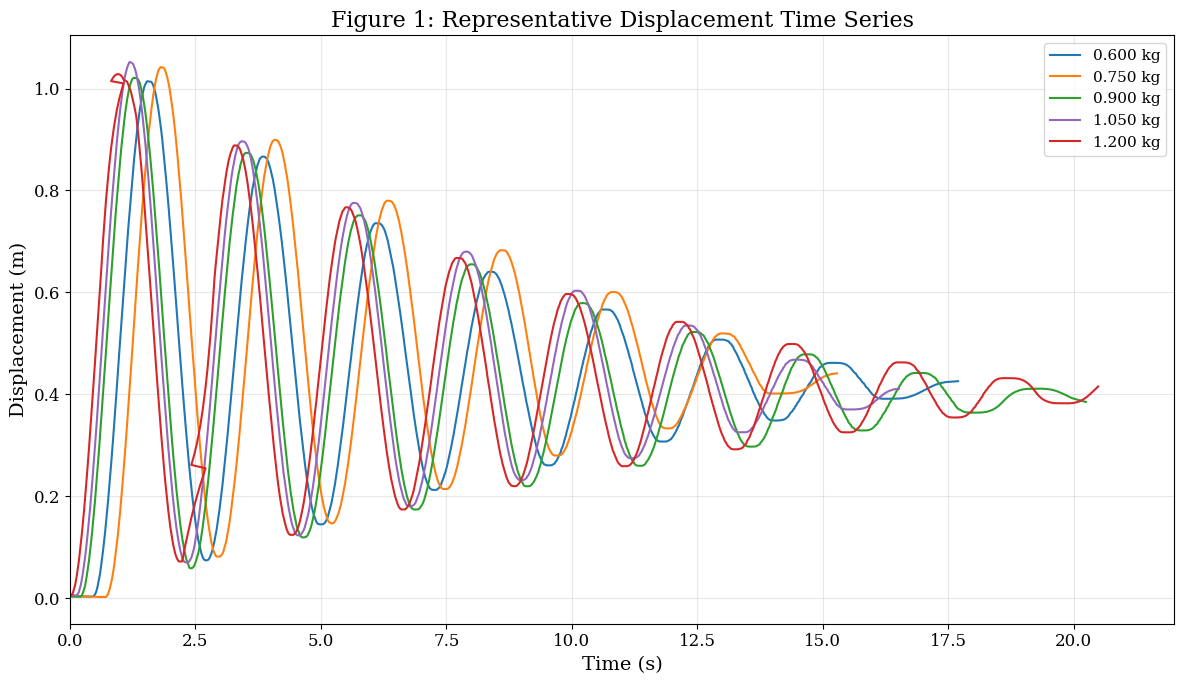

✓ Figure 1 displayed and saved

FIGURE 2: QSpace Classification - All 15 Runs


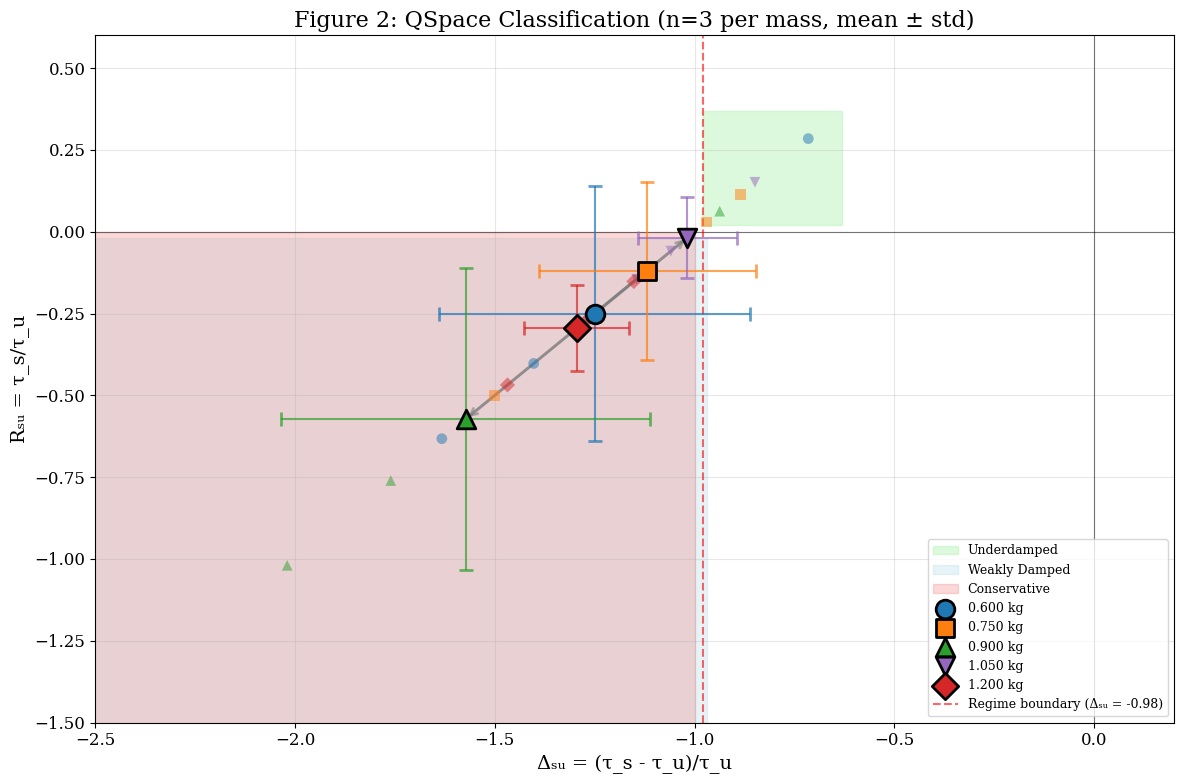

✓ Figure 2 displayed and saved

FIGURE 3: Δₛᵤ vs Mass with Error Bars


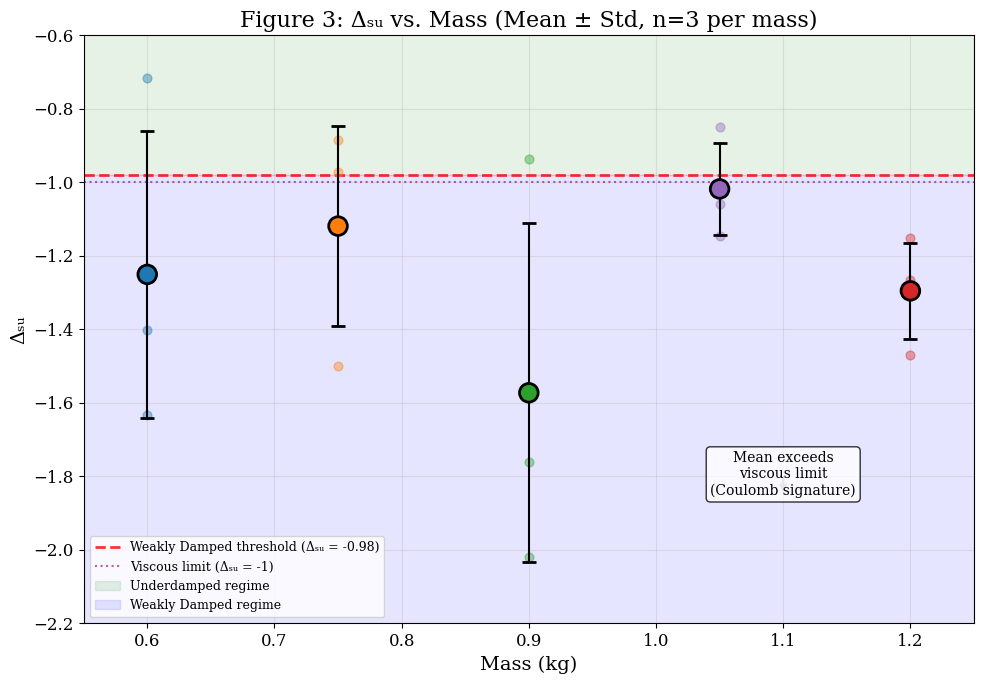

✓ Figure 3 displayed and saved

FIGURE 4: Probability of Weakly Damped Classification


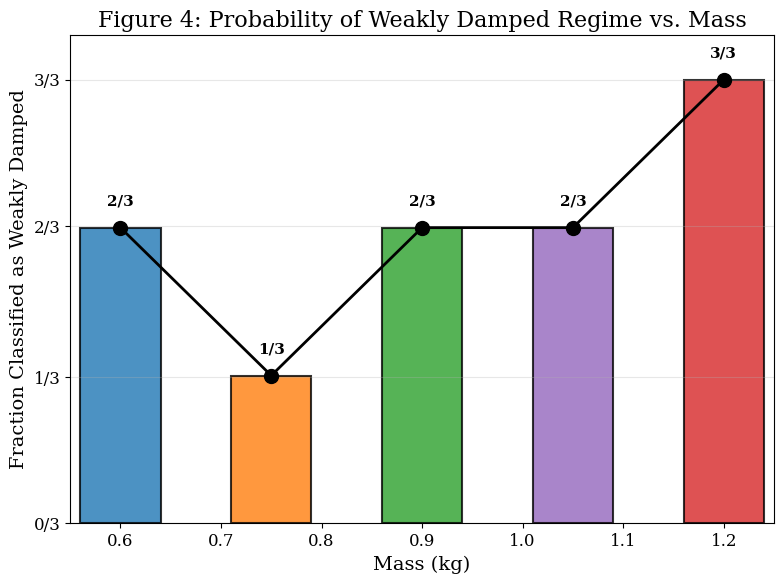

✓ Figure 4 displayed and saved

FIGURE 5: Timescales vs Mass with Error Bars


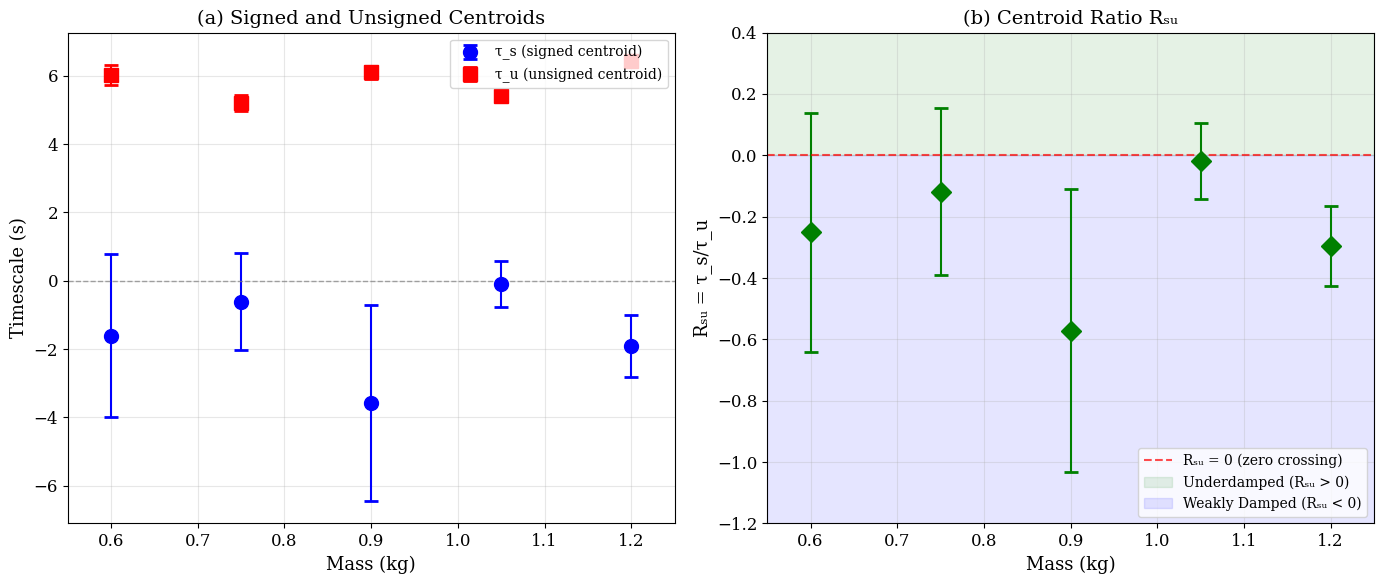

✓ Figure 5 displayed and saved

LATEX TABLE
\begin{table}[htbp]
\centering
\caption{QSignature diagnostics for curved track oscillator (mean $\pm$ standard deviation, $n=3$ per mass).}
\label{tab:QSignature_triplicate}
\begin{tabular}{lccccc}
\hline
Mass & $\Delta_{su}$ & $R_{su}$ & $\tau_s$ (s) & $\tau_u$ (s) & U/W \\
\hline
0.600 kg & -1.250$\pm$0.390 & -0.250$\pm$0.390 & -1.613$\pm$2.384 & 6.025$\pm$0.297 & 1/2 \\
0.750 kg & -1.119$\pm$0.272 & -0.119$\pm$0.272 & -0.609$\pm$1.421 & 5.203$\pm$0.225 & 2/1 \\
0.900 kg & -1.572$\pm$0.461 & -0.572$\pm$0.461 & -3.581$\pm$2.873 & 6.103$\pm$0.191 & 1/2 \\
1.050 kg & -1.018$\pm$0.124 & -0.018$\pm$0.124 & -0.098$\pm$0.674 & 5.414$\pm$0.021 & 1/2 \\
1.200 kg & -1.295$\pm$0.131 & -0.295$\pm$0.131 & -1.920$\pm$0.905 & 6.432$\pm$0.180 & 0/3 \\
\hline
\end{tabular}
\end{table}

ALL FILES SAVED TO: /home/ahmad/Yandex.Disk/Research/Q theory/QSignature Portugal paper 2026
Files generated:
  • fig1_triplicate.png, fig1_triplicate.pdf
  • fig2_triplicat

In [3]:
"""
FINAL Figure Generation for ICMASC 2026 Paper - TRIPLICATE DATA

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from QSignature import compute_all, QSmooth
import os
import warnings
warnings.filterwarnings('ignore')

# Setup
OUTPUT_DIR = "write your output directory here"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif',
    'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# ============================================================================
# LOAD DATA
# ============================================================================
print("="*80)
print("LOADING TRIPLICATE EXPERIMENTAL DATA")
print("="*80)

data_dict = data_files
for name, df in data_dict.items():
    print(f"  {name}: {len(df)} points, t ∈ [{df.index[0]:.2f}, {df.index[-1]:.2f}] s")

mass_groups = {
    "0g": ["0g1", "0g2", "0g3"],
    "150g": ["150g1", "150g2", "150g3"],
    "300g": ["300g1", "300g2", "300g3"],
    "450g": ["450g1", "450g2", "450g3"],
    "600g": ["600g1", "600g2", "600g3"],
}

mass_values_kg = {"0g": 0.600, "150g": 0.750, "300g": 0.900, "450g": 1.050, "600g": 1.200}
mass_labels = ["0.600 kg", "0.750 kg", "0.900 kg", "1.050 kg", "1.200 kg"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]
markers = ['o', 's', '^', 'v', 'D']
qs = QSmooth()

# ============================================================================
# COMPUTE QSignature METRICS FOR ALL RUNS
# ============================================================================
print("\n" + "="*80)
print("COMPUTING QSignature METRICS FOR ALL RUNS")
print("="*80)

all_results = {}
for name, df in data_dict.items():
    t = df.index.values
    R = df.iloc[:, 0].values
    R_smooth = qs.savgol(t, R, window_frac=0.05, polyorder=3)
    results = compute_all(t, R_smooth, verbose=False)
    
    tau_s_val = results.get('tau_s', np.nan)
    tau_u_val = results.get('tau_u', np.nan)
    
    # Only keep reliable estimators (no τ_env, no Δ₂₃ᵉⁿᵛ)
    all_results[name] = {
        'Δₛᵤ': results.get('Delta_su', np.nan),
        'Rₛᵤ': tau_s_val / tau_u_val if tau_u_val != 0 else np.nan,
        'τ_s': tau_s_val,
        'τ_u': tau_u_val,
    }
    
    delta_su = all_results[name]['Δₛᵤ']
    regime = "Underdamped" if delta_su > -0.98 else "Weakly Damped"
    all_results[name]['Regime'] = regime
    
    print(f"  {name}: Δₛᵤ = {delta_su:+.4f} → {regime}")

# ============================================================================
# COMPUTE MEANS AND STANDARD DEVIATIONS BY MASS GROUP
# ============================================================================
print("\n" + "="*80)
print("MEANS AND STANDARD DEVIATIONS BY MASS")
print("="*80)

summary_stats = {}
regime_counts = {}

for mass, runs in mass_groups.items():
    delta_vals = [all_results[r]['Δₛᵤ'] for r in runs]
    r_su_vals = [all_results[r]['Rₛᵤ'] for r in runs]
    tau_s_vals = [all_results[r]['τ_s'] for r in runs]
    tau_u_vals = [all_results[r]['τ_u'] for r in runs]
    
    regimes = [all_results[r]['Regime'] for r in runs]
    underdamped_count = regimes.count("Underdamped")
    weakly_damped_count = regimes.count("Weakly Damped")
    regime_counts[mass] = {'Underdamped': underdamped_count, 'Weakly Damped': weakly_damped_count}
    
    summary_stats[mass] = {
        'Δₛᵤ_mean': np.mean(delta_vals),
        'Δₛᵤ_std': np.std(delta_vals),
        'Rₛᵤ_mean': np.mean(r_su_vals),
        'Rₛᵤ_std': np.std(r_su_vals),
        'τ_s_mean': np.mean(tau_s_vals),
        'τ_s_std': np.std(tau_s_vals),
        'τ_u_mean': np.mean(tau_u_vals),
        'τ_u_std': np.std(tau_u_vals),
        'n_underdamped': underdamped_count,
        'n_weakly_damped': weakly_damped_count,
    }
    
    print(f"\n{mass} (n=3):")
    print(f"  Δₛᵤ   = {summary_stats[mass]['Δₛᵤ_mean']:+.4f} ± {summary_stats[mass]['Δₛᵤ_std']:.4f}")
    print(f"  Rₛᵤ   = {summary_stats[mass]['Rₛᵤ_mean']:+.4f} ± {summary_stats[mass]['Rₛᵤ_std']:.4f}")
    print(f"  τ_s   = {summary_stats[mass]['τ_s_mean']:+.4f} ± {summary_stats[mass]['τ_s_std']:.4f} s")
    print(f"  τ_u   = {summary_stats[mass]['τ_u_mean']:.4f} ± {summary_stats[mass]['τ_u_std']:.4f} s")
    print(f"  Classification: {underdamped_count} Underdamped, {weakly_damped_count} Weakly Damped")

# ============================================================================
# TABLE 1: Summary Statistics (for manuscript) - UPDATED without τ_env and Δ₂₃ᵉⁿᵛ
# ============================================================================
print("\n" + "="*80)
print("TABLE 1: SUMMARY STATISTICS (MEAN ± STD, n=3)")
print("="*80)

table_data = []
for i, mass in enumerate(["0g", "150g", "300g", "450g", "600g"]):
    s = summary_stats[mass]
    table_data.append([
        mass_labels[i],
        f"{s['Δₛᵤ_mean']:.3f} ± {s['Δₛᵤ_std']:.3f}",
        f"{s['Rₛᵤ_mean']:.3f} ± {s['Rₛᵤ_std']:.3f}",
        f"{s['τ_s_mean']:.3f} ± {s['τ_s_std']:.3f}",
        f"{s['τ_u_mean']:.3f} ± {s['τ_u_std']:.3f}",
        f"{s['n_underdamped']}/{s['n_weakly_damped']}"
    ])

df_table = pd.DataFrame(table_data, 
    columns=['Mass', 'Δₛᵤ', 'Rₛᵤ', 'τ_s (s)', 'τ_u (s)', 'U/W'])
print(df_table.to_string(index=False))
df_table.to_csv(os.path.join(OUTPUT_DIR, 'table1_triplicate.csv'), index=False)

# ============================================================================
# FIGURE 1: Representative Displacement Time Series
# ============================================================================
print("\n" + "="*80)
print("FIGURE 1: Representative Displacement Time Series")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 7))
representative_runs = {"0g": "0g1", "150g": "150g1", "300g": "300g1", "450g": "450g1", "600g": "600g1"}

for i, (mass, run) in enumerate(representative_runs.items()):
    df = data_dict[run]
    t = df.index.values
    R = df.iloc[:, 0].values
    R_smooth = qs.savgol(t, R, window_frac=0.05, polyorder=3)
    ax.plot(t, R_smooth, color=colors[i], linewidth=1.5, label=mass_labels[i])

ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Displacement (m)', fontsize=14)
ax.set_title('Figure 1: Representative Displacement Time Series', fontsize=16)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 22])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_triplicate.png'), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_triplicate.pdf'))
plt.show()
print("✓ Figure 1 displayed and saved")

# ============================================================================
# FIGURE 2: QSpace Plot with All 15 Points
# ============================================================================
print("\n" + "="*80)
print("FIGURE 2: QSpace Classification - All 15 Runs")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 8))

# Regime regions (from QSignature paper)
regions = {
    'Underdamped': {'x_range': [-0.98, -0.63], 'y_range': [0.02, 0.37], 'color': 'lightgreen'},
    'Weakly Damped': {'x_range': [-2.55, -0.97], 'y_range': [-1.55, -0.02], 'color': 'lightblue'},
    'Conservative': {'x_range': [-3.02, -1.00], 'y_range': [-2.02, 0], 'color': 'lightcoral'},
}
for regime, bounds in regions.items():
    x_poly = [bounds['x_range'][0], bounds['x_range'][1], bounds['x_range'][1], bounds['x_range'][0], bounds['x_range'][0]]
    y_poly = [bounds['y_range'][0], bounds['y_range'][0], bounds['y_range'][1], bounds['y_range'][1], bounds['y_range'][0]]
    ax.fill(x_poly, y_poly, alpha=0.3, color=bounds['color'], label=regime)

# Plot all individual points with lower alpha
for mass, runs in mass_groups.items():
    i = list(mass_groups.keys()).index(mass)
    for run in runs:
        delta = all_results[run]['Δₛᵤ']
        r_su = all_results[run]['Rₛᵤ']
        ax.scatter(delta, r_su, color=colors[i], marker=markers[i], s=60, 
                   alpha=0.5, edgecolor='none', zorder=5)

# Plot means with larger markers and error bars
mass_list = ["0g", "150g", "300g", "450g", "600g"]
for i, mass in enumerate(mass_list):
    delta_mean = summary_stats[mass]['Δₛᵤ_mean']
    delta_std = summary_stats[mass]['Δₛᵤ_std']
    r_su_mean = summary_stats[mass]['Rₛᵤ_mean']
    r_su_std = summary_stats[mass]['Rₛᵤ_std']
    
    ax.errorbar(delta_mean, r_su_mean, xerr=delta_std, yerr=r_su_std,
                fmt='none', ecolor=colors[i], capsize=5, capthick=2, alpha=0.7, zorder=9)
    ax.scatter(delta_mean, r_su_mean, color=colors[i], marker=markers[i], s=180, 
               edgecolor='black', linewidth=2, zorder=10, label=mass_labels[i])

# Arrow showing mass increase direction
for i in range(4):
    ax.annotate('', xy=(summary_stats[mass_list[i+1]]['Δₛᵤ_mean'], summary_stats[mass_list[i+1]]['Rₛᵤ_mean']),
                xytext=(summary_stats[mass_list[i]]['Δₛᵤ_mean'], summary_stats[mass_list[i]]['Rₛᵤ_mean']),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2, alpha=0.6))

ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='black', linewidth=0.8, alpha=0.5)
ax.axvline(x=-0.98, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Regime boundary (Δₛᵤ = -0.98)')
ax.set_xlabel('Δₛᵤ = (τ_s - τ_u)/τ_u', fontsize=14)
ax.set_ylabel('Rₛᵤ = τ_s/τ_u', fontsize=14)
ax.set_title('Figure 2: QSpace Classification (n=3 per mass, mean ± std)', fontsize=16)
ax.set_xlim([-2.5, 0.2])
ax.set_ylim([-1.5, 0.6])
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_triplicate.png'), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_triplicate.pdf'))
plt.show()
print("✓ Figure 2 displayed and saved")

# ============================================================================
# FIGURE 3: Δₛᵤ vs Mass with Error Bars
# ============================================================================
print("\n" + "="*80)
print("FIGURE 3: Δₛᵤ vs Mass with Error Bars")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 7))

mass_kg = np.array([mass_values_kg[m] for m in mass_list])
delta_means = np.array([summary_stats[m]['Δₛᵤ_mean'] for m in mass_list])
delta_stds = np.array([summary_stats[m]['Δₛᵤ_std'] for m in mass_list])

# Plot individual points (all 15 trials)
for i, mass in enumerate(mass_list):
    runs = mass_groups[mass]
    delta_vals = [all_results[r]['Δₛᵤ'] for r in runs]
    ax.scatter([mass_kg[i]]*3, delta_vals, color=colors[i], alpha=0.4, s=40, zorder=5)

# Plot means with error bars
ax.errorbar(mass_kg, delta_means, yerr=delta_stds, fmt='none', ecolor='black', capsize=5, capthick=2, zorder=9)
ax.scatter(mass_kg, delta_means, color=colors, s=180, edgecolor='black', linewidth=2, zorder=10)

# Regime boundaries
ax.axhline(y=-0.98, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Weakly Damped threshold (Δₛᵤ = -0.98)')
ax.axhline(y=-1.0, color='purple', linestyle=':', linewidth=1.5, alpha=0.6, label='Viscous limit (Δₛᵤ = -1)')

# Shade regime regions
ax.axhspan(-0.98, 0, alpha=0.1, color='green', label='Underdamped regime')
ax.axhspan(-2.5, -0.98, alpha=0.1, color='blue', label='Weakly Damped regime')

# Annotation for deviation from viscous limit
ax.annotate('Mean exceeds\nviscous limit\n(Coulomb signature)', 
            xy=(1.1, -1.85), xytext=(1.1, -1.85),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            fontsize=10, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Mass (kg)', fontsize=14)
ax.set_ylabel('Δₛᵤ', fontsize=14)
ax.set_title('Figure 3: Δₛᵤ vs. Mass (Mean ± Std, n=3 per mass)', fontsize=16)
ax.set_xlim([0.55, 1.25])
ax.set_ylim([-2.2, -0.6])
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_triplicate.png'), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_triplicate.pdf'))
plt.show()
print("✓ Figure 3 displayed and saved")

# ============================================================================
# FIGURE 4: Classification Probability vs Mass
# ============================================================================
print("\n" + "="*80)
print("FIGURE 4: Probability of Weakly Damped Classification")
print("="*80)

fig, ax = plt.subplots(figsize=(8, 6))

prob_weakly = np.array([summary_stats[m]['n_weakly_damped']/3 for m in mass_list])

ax.bar(mass_kg, prob_weakly, width=0.08, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.plot(mass_kg, prob_weakly, 'k-', linewidth=2, marker='o', markersize=10)

ax.set_xlabel('Mass (kg)', fontsize=14)
ax.set_ylabel('Fraction Classified as Weakly Damped', fontsize=14)
ax.set_title('Figure 4: Probability of Weakly Damped Regime vs. Mass', fontsize=16)
ax.set_xlim([0.55, 1.25])
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
ax.set_yticks([0, 0.33, 0.67, 1.0])
ax.set_yticklabels(['0/3', '1/3', '2/3', '3/3'])

for i, (mass, prob) in enumerate(zip(mass_kg, prob_weakly)):
    ax.text(mass, prob + 0.05, f"{int(prob*3)}/3", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_probability.png'), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_probability.pdf'))
plt.show()
print("✓ Figure 4 displayed and saved")

# ============================================================================
# FIGURE 5: Timescales with Error Bars
# ============================================================================
print("\n" + "="*80)
print("FIGURE 5: Timescales vs Mass with Error Bars")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

tau_s_means = np.array([summary_stats[m]['τ_s_mean'] for m in mass_list])
tau_s_stds = np.array([summary_stats[m]['τ_s_std'] for m in mass_list])
tau_u_means = np.array([summary_stats[m]['τ_u_mean'] for m in mass_list])
tau_u_stds = np.array([summary_stats[m]['τ_u_std'] for m in mass_list])
r_su_means = np.array([summary_stats[m]['Rₛᵤ_mean'] for m in mass_list])
r_su_stds = np.array([summary_stats[m]['Rₛᵤ_std'] for m in mass_list])

# Panel (a) - Timescales
ax1.errorbar(mass_kg, tau_s_means, yerr=tau_s_stds, fmt='o', color='blue', capsize=5, capthick=2, markersize=10, label='τ_s (signed centroid)')
ax1.errorbar(mass_kg, tau_u_means, yerr=tau_u_stds, fmt='s', color='red', capsize=5, capthick=2, markersize=10, label='τ_u (unsigned centroid)')
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_xlabel('Mass (kg)', fontsize=13)
ax1.set_ylabel('Timescale (s)', fontsize=13)
ax1.set_title('(a) Signed and Unsigned Centroids', fontsize=14)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0.55, 1.25])

# Panel (b) - R_su
ax2.errorbar(mass_kg, r_su_means, yerr=r_su_stds, fmt='D', color='green', capsize=5, capthick=2, markersize=10)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Rₛᵤ = 0 (zero crossing)')
ax2.axhspan(0, 0.6, alpha=0.1, color='green', label='Underdamped (Rₛᵤ > 0)')
ax2.axhspan(-1.5, 0, alpha=0.1, color='blue', label='Weakly Damped (Rₛᵤ < 0)')
ax2.set_xlabel('Mass (kg)', fontsize=13)
ax2.set_ylabel('Rₛᵤ = τ_s/τ_u', fontsize=13)
ax2.set_title('(b) Centroid Ratio Rₛᵤ', fontsize=14)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0.55, 1.25])
ax2.set_ylim([-1.2, 0.4])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig5_timescales_triplicate.png'), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig5_timescales_triplicate.pdf'))
plt.show()
print("✓ Figure 5 displayed and saved")

# ============================================================================
# LATEX TABLE FOR MANUSCRIPT - UPDATED without τ_env and Δ₂₃ᵉⁿᵛ
# ============================================================================
latex_table = """\\begin{table}[htbp]
\\centering
\\caption{QSignature diagnostics for curved track oscillator (mean $\\pm$ standard deviation, $n=3$ per mass).}
\\label{tab:QSignature_triplicate}
\\begin{tabular}{lccccc}
\\hline
Mass & $\\Delta_{su}$ & $R_{su}$ & $\\tau_s$ (s) & $\\tau_u$ (s) & U/W \\\\
\\hline
"""
for i, mass in enumerate(["0g", "150g", "300g", "450g", "600g"]):
    s = summary_stats[mass]
    latex_table += f"{mass_labels[i]} & {s['Δₛᵤ_mean']:.3f}$\\pm${s['Δₛᵤ_std']:.3f} & {s['Rₛᵤ_mean']:.3f}$\\pm${s['Rₛᵤ_std']:.3f} & {s['τ_s_mean']:.3f}$\\pm${s['τ_s_std']:.3f} & {s['τ_u_mean']:.3f}$\\pm${s['τ_u_std']:.3f} & {s['n_underdamped']}/{s['n_weakly_damped']} \\\\\n"
latex_table += "\\hline\n\\end{tabular}\n\\end{table}"

with open(os.path.join(OUTPUT_DIR, 'table1_triplicate.tex'), 'w') as f:
    f.write(latex_table)

print("\n" + "="*80)
print("LATEX TABLE")
print("="*80)
print(latex_table)

print("\n" + "="*80)
print(f"ALL FILES SAVED TO: {OUTPUT_DIR}")
print("="*80)
print("Files generated:")
print("  • fig1_triplicate.png, fig1_triplicate.pdf")
print("  • fig2_triplicate.png, fig2_triplicate.pdf")
print("  • fig3_triplicate.png, fig3_triplicate.pdf")
print("  • fig4_probability.png, fig4_probability.pdf")
print("  • fig5_timescales_triplicate.png, fig5_timescales_triplicate.pdf")
print("  • table1_triplicate.csv, table1_triplicate.tex")
print("\n✅ Ready for manuscript revision.")

# Figure 6 generation code

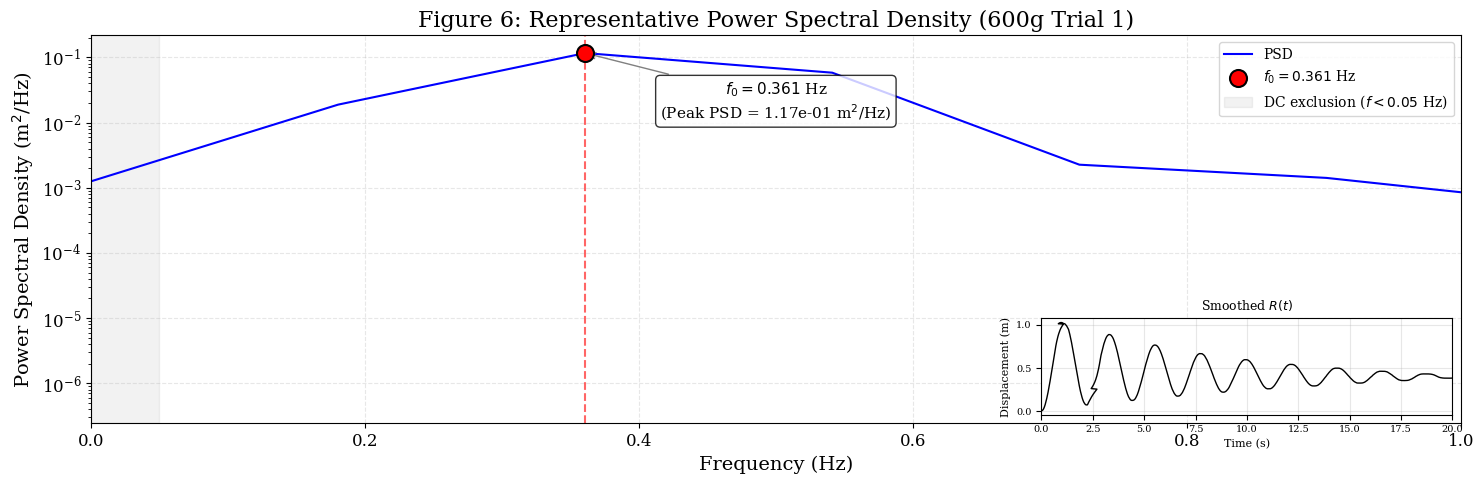

Figure 6 saved to: /home/ahmad/Yandex.Disk/Research/Q theory/QSignature Portugal paper 2026
  Fundamental frequency: f₀ = 0.3608 Hz
  Peak PSD: 1.1654e-01 m²/Hz
  Only a single dominant peak is observed—no secondary mode present.


In [5]:
"""
Generate Figure 6: Representative Power Spectral Density (PSD) Plot
for the 600g (1.2kg) trial 1 data.

Shows a single dominant peak at the fundamental pendulum frequency.
The absence of secondary peaks confirms that the time-domain frequency
bias arises from Coulomb-induced waveform distortion, not a secondary
oscillatory mode.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from QSignature import QSmooth, compute_all
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os

# Setup
OUTPUT_DIR = "write your directory here"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif',
    'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# Load the 600g trial 1 data
df = pd.read_csv("directory you saved the file", index_col=0)
t = df.index.values
R_raw = df.iloc[:, 0].values

# Detrend by subtracting mean
R_detrend = R_raw - np.mean(R_raw)

# Sampling frequency
dt = np.mean(np.diff(t))
fs = 1.0 / dt

# Compute PSD using Welch's method
nperseg = min(256, len(R_detrend)//2)
freqs, psd = welch(R_detrend, fs=fs, nperseg=nperseg, noverlap=nperseg//2)

# Find the dominant peak (ignore DC near f=0)
valid_idx = freqs > 0.05
peak_idx = np.argmax(psd[valid_idx])
f0 = freqs[valid_idx][peak_idx]
psd_peak = psd[valid_idx][peak_idx]

# Create figure
fig, ax = plt.subplots(figsize=(15, 5))

# Plot PSD
ax.semilogy(freqs, psd, 'b-', linewidth=1.5, label='PSD')
ax.scatter(f0, psd_peak, color='red', s=150, edgecolor='black', linewidth=1.5, 
           zorder=10, label=f'$f_0 = {f0:.3f}$ Hz')

# Add vertical line at peak
ax.axvline(x=f0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

# Shade the DC exclusion region
ax.axvspan(0, 0.05, alpha=0.1, color='gray', label='DC exclusion ($f < 0.05$ Hz)')

# Annotate the peak

# Annotate the peak — place text in the open right region of the plot
ax.annotate(f'$f_0 = {f0:.3f}$ Hz\n(Peak PSD = {psd_peak:.2e} m$^2$/Hz)',
            xy=(f0, psd_peak), 
            xytext=(0.5, psd_peak * 0.1),  # Move to center-right area
            arrowprops=dict(arrowstyle='->', color='gray', lw=1),
            fontsize=11,
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))








ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Power Spectral Density (m$^2$/Hz)', fontsize=14)
ax.set_title('Figure 6: Representative Power Spectral Density (600g Trial 1)', fontsize=16)
ax.set_xlim([0, 1.0])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=10)

# Add inset showing the time series for context
inset_ax = inset_axes(ax, width="30%", height="25%", loc='lower right')
qs = QSmooth()
R_smooth = qs.savgol(t, R_raw, window_frac=0.05, polyorder=3)
inset_ax.plot(t, R_smooth, 'k-', linewidth=1)
inset_ax.set_xlabel('Time (s)', fontsize=8)
inset_ax.set_ylabel('Displacement (m)', fontsize=8)
inset_ax.set_title('Smoothed $R(t)$', fontsize=9)
inset_ax.grid(True, alpha=0.3)
inset_ax.set_xlim([0, 20])
inset_ax.tick_params(axis='both', which='major', labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig6_psd_example.png'), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig6_psd_example.pdf'))
plt.show()

print(f"Figure 6 saved to: {OUTPUT_DIR}")
print(f"  Fundamental frequency: f₀ = {f0:.4f} Hz")
print(f"  Peak PSD: {psd_peak:.4e} m²/Hz")
print(f"  Only a single dominant peak is observed—no secondary mode present.")

# Figure 1 better


FIGURE 1: 0.6 kg vs 1.2 kg Displacement Comparison


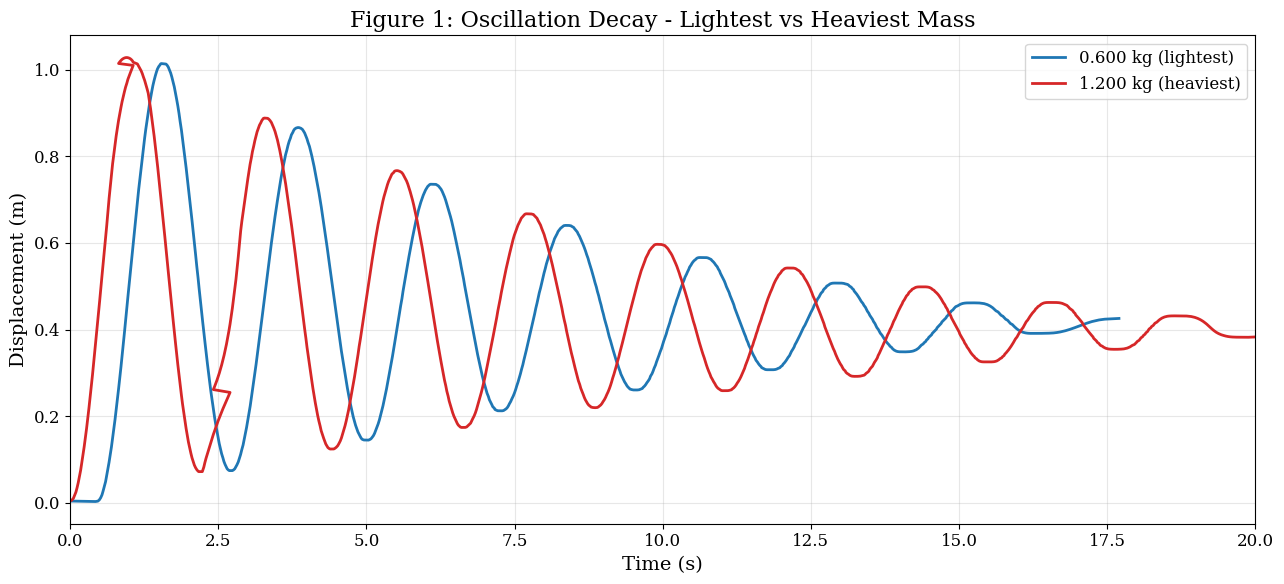

✓ Figure 1 saved (lightest vs heaviest comparison)


In [6]:
# ============================================================================
# FIGURE 1: Displacement Comparison (0.6 kg vs 1.2 kg only)
# ============================================================================
print("\n" + "="*80)
print("FIGURE 1: 0.6 kg vs 1.2 kg Displacement Comparison")
print("="*80)

fig, ax = plt.subplots(figsize=(13, 6))

# Representative runs for lightest and heaviest
run_light = "0g1"
run_heavy = "600g1"

for run, label, color in [(run_light, "0.600 kg (lightest)", "#1f77b4"), 
                           (run_heavy, "1.200 kg (heaviest)", "#d62728")]:
    df = data_dict[run]
    t = df.index.values
    R = df.iloc[:, 0].values
    R_smooth = qs.savgol(t, R, window_frac=0.05, polyorder=3)
    ax.plot(t, R_smooth, color=color, linewidth=2, label=label)

ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Displacement (m)', fontsize=14)
ax.set_title('Figure 1: Oscillation Decay - Lightest vs Heaviest Mass', fontsize=16)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 20])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_triplicate.png'), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_triplicate.pdf'))
plt.show()
print("✓ Figure 1 saved (lightest vs heaviest comparison)")